# Flood analysis: statistics on the OSM street network
Made by: Giovanni Guarnieri Soares

Statistical analysis of the street-level flood data built by `Flood_analysis_OSMNX.ipynb`.
Sections:

1. **Group comparison** — flooded vs non-flooded streets: distributions, Mann-Whitney U tests with
   multiple-comparison correction and effect sizes, Spearman correlations with flood counts, and a
   spatial-autocorrelation check (Moran's I).
2. **Elevation-controlled regression** — does street-network centrality predict flooding *after*
   controlling for terrain (elevation, slope) and street attributes?
3. **Predictive model** — random forest / gradient boosting with **spatial** (district-blocked)
   cross-validation, permutation importances, and a flood-probability map.
4. **Resilience simulation** — impact of removing flooded streets on network efficiency, against
   random and betweenness-targeted baselines.
5. **Temporal analysis** — seasonality and duration-weighted results.

The metric set includes **vulnerability** — each street's direct impact on network efficiency when
removed, V(s) = (E − E₋ₛ)/E, precomputed by `compute_vulnerability.py` into
`results/vulnerability.csv`. Eigenvector centrality is excluded (localization pathology: medians
are zero in both flood groups, the ranking is boundary-unstable, and it carries no signal after
elevation adjustment).

Inputs (all produced by the pipeline notebook or shipped in the repo): `edges_centrals.csv`,
`central_graph.graphml`, `matched_events.csv`, `floods.csv`, `Shapes/DI2010_RMSP_CEM.shp`,
`results/vulnerability.csv`.
Figures are written to `figures/`, result tables to `results/`.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
from shapely import wkt

from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)
RESDIR = "results"; os.makedirs(RESDIR, exist_ok=True)
CRS_METRIC = "EPSG:31983"  # SIRGAS 2000 / UTM 23S

edges = pd.read_csv("edges_centrals.csv")
edges["geometry"] = edges["geometry"].apply(wkt.loads)
edges = gpd.GeoDataFrame(edges, geometry="geometry", crs="EPSG:4326")
edges["flood_any"] = edges["flood_count"] > 0  # derive from the count to be robust to CSV round-trips

# Per-street vulnerability V(s) = (E - E_-s)/E, E = global efficiency of the line graph
# (computed by compute_vulnerability.py — igraph, ~9 h single-core, checkpointed)
vuln = pd.read_csv(f"{RESDIR}/vulnerability.csv")
edges = edges.merge(vuln[["u", "v", "key", "vulnerability"]], on=["u", "v", "key"], how="left")

# Eigenvector centrality is excluded: it localizes on the densest cluster (medians are zero in
# both flood groups), its ranking is unstable to the network boundary, and it carries no signal
# after elevation adjustment.
CENTRALITIES = {
    "Degree": "Degree",
    "Mean Shortest Path Length": "Mean shortest path length",
    "Closeness": "Closeness",
    "bet": "Betweenness",
    "Subgraph Centrality": "Subgraph centrality",
    "Pagerank": "PageRank",
    "vulnerability": "Vulnerability",
}
TERRAIN = ["elevation", "grade_abs"]
LABELS = {**CENTRALITIES, "elevation": "Elevation (m)", "grade_abs": "Absolute grade"}

flooded = edges[edges["flood_any"]]
non_flooded = edges[~edges["flood_any"]]
print(f"{len(edges)} street edges, {len(flooded)} flooded ({len(flooded) / len(edges):.1%}), "
      f"{edges['flood_count'].sum():.0f} matched flood events")

8714 street edges, 137 flooded (1.6%), 282 matched flood events


## 1. Group comparison: flooded vs non-flooded streets

<ipython-input-1-89e652fa2204>:29: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



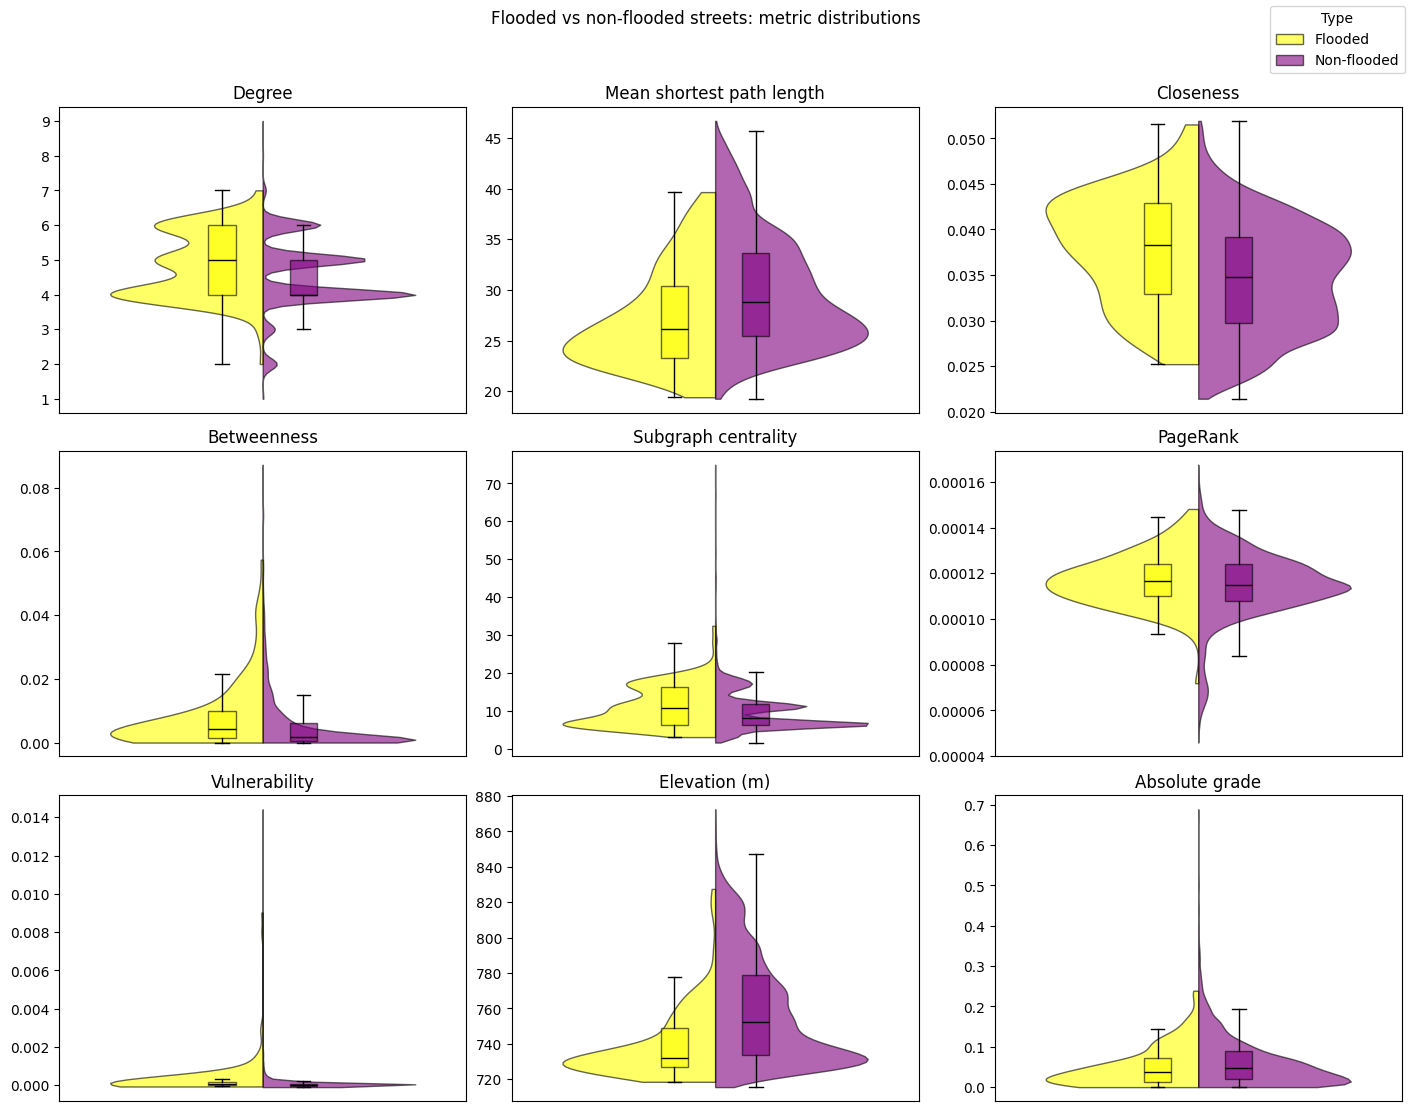

In [2]:
# Split violins: flooded on the left (yellow), non-flooded on the right (purple), box plot inside.
# Drawn with matplotlib — plotly/kaleido renders empty violin bodies on this machine.
from matplotlib.patches import Patch

plot_cols = list(CENTRALITIES) + TERRAIN

fig, axes = plt.subplots(3, 3, figsize=(14, 11), layout="constrained")
for ax, c in zip(axes.flat, plot_cols):
    for data, side, color in ((flooded[c].dropna(), -1, "yellow"),
                              (non_flooded[c].dropna(), 1, "purple")):
        parts = ax.violinplot(data, positions=[0], widths=0.9, showextrema=False)
        body = parts["bodies"][0]
        verts = body.get_paths()[0].vertices
        verts[:, 0] = np.clip(verts[:, 0], 0, None) if side > 0 else np.clip(verts[:, 0], None, 0)
        body.set_facecolor(color); body.set_edgecolor("black"); body.set_alpha(0.6)
        bp = ax.boxplot(data, positions=[0.12 * side], widths=0.08, showfliers=False,
                        patch_artist=True, medianprops=dict(color="black"))
        bp["boxes"][0].set_facecolor(color); bp["boxes"][0].set_alpha(0.6)
    ax.set_title(LABELS[c])
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)

fig.suptitle("Flooded vs non-flooded streets: metric distributions")
fig.legend(handles=[Patch(facecolor="yellow", edgecolor="black", alpha=0.6, label="Flooded"),
                    Patch(facecolor="purple", edgecolor="black", alpha=0.6, label="Non-flooded")],
           loc="outside upper right", title="Type")
plt.savefig(f"{FIGDIR}/violins_all_metrics.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/violins_all_metrics.pdf", bbox_inches="tight")
plt.show()

In [3]:
# Mann-Whitney U per metric with Holm / Benjamini-Hochberg corrections and
# rank-biserial correlation as effect size (>0: flooded streets have HIGHER values).
# Spearman correlation uses the event COUNT per street, not just the flooded/not split.
rows = []
n1, n2 = len(flooded), len(non_flooded)
for c in plot_cols:
    U, p = mannwhitneyu(flooded[c].dropna(), non_flooded[c].dropna(), alternative="two-sided")
    rbc = 2 * U / (len(flooded[c].dropna()) * len(non_flooded[c].dropna())) - 1
    ok = edges[[c, "flood_count"]].dropna()
    rho, p_rho = spearmanr(ok[c], ok["flood_count"])
    rows.append({"metric": LABELS[c],
                 "median_flooded": flooded[c].median(), "median_non_flooded": non_flooded[c].median(),
                 "U": U, "p_MWU": p, "rank_biserial": rbc,
                 "spearman_vs_count": rho, "p_spearman": p_rho})

tests = pd.DataFrame(rows)
tests["p_MWU_holm"] = multipletests(tests["p_MWU"], method="holm")[1]
tests["p_MWU_BH"] = multipletests(tests["p_MWU"], method="fdr_bh")[1]
tests["p_spearman_BH"] = multipletests(tests["p_spearman"], method="fdr_bh")[1]
tests.to_csv(f"{RESDIR}/group_comparison_tests.csv", index=False)
tests.round(4)

Out[1]: 
                      metric  median_flooded  ...  p_MWU_BH  p_spearman_BH
0                     Degree          5.0000  ...    0.0009         0.0009
1  Mean shortest path length         26.1058  ...    0.0000         0.0000
2                  Closeness          0.0383  ...    0.0000         0.0000
3                Betweenness          0.0042  ...    0.0000         0.0000
4        Subgraph centrality         10.7094  ...    0.0246         0.0238
5                   PageRank          0.0001  ...    0.1635         0.1613
6              Vulnerability          0.0001  ...    0.0000         0.0000
7              Elevation (m)        732.0000  ...    0.0000         0.0000
8             Absolute grade          0.0370  ...    0.0246         0.0238

[9 rows x 11 columns]


                      metric  median_flooded  ...  p_MWU_BH  p_spearman_BH
0                     Degree          5.0000  ...    0.0009         0.0009
1  Mean shortest path length         26.1058  ...    0.0000         0.0000
2                  Closeness          0.0383  ...    0.0000         0.0000
3                Betweenness          0.0042  ...    0.0000         0.0000
4        Subgraph centrality         10.7094  ...    0.0246         0.0238
5                   PageRank          0.0001  ...    0.1635         0.1613
6              Vulnerability          0.0001  ...    0.0000         0.0000
7              Elevation (m)        732.0000  ...    0.0000         0.0000
8             Absolute grade          0.0370  ...    0.0246         0.0238

[9 rows x 11 columns]

**Spatial autocorrelation caveat.** Flooded streets cluster along drainage lines, so edges are not
independent observations and the Mann-Whitney p-values above are optimistic. Moran's I below quantifies
this clustering; the regression and spatially blocked cross-validation in the next sections are the
analyses that take the structure into account.

In [4]:
from libpysal.weights import KNN
from esda.moran import Moran

# KNN spatial weights on edge midpoints (metric CRS)
midpoints = gpd.GeoDataFrame(geometry=edges.to_crs(CRS_METRIC).geometry.interpolate(0.5, normalized=True))
w = KNN.from_dataframe(midpoints, k=8)
w.transform = "r"

mi_any = Moran(edges["flood_any"].astype(int).values, w, permutations=999)
mi_cnt = Moran(edges["flood_count"].values, w, permutations=999)
print(f"Moran's I, flood_any:   I = {mi_any.I:.4f} (E[I] = {mi_any.EI:.4f}), p_sim = {mi_any.p_sim:.4f}")
print(f"Moran's I, flood_count: I = {mi_cnt.I:.4f} (E[I] = {mi_cnt.EI:.4f}), p_sim = {mi_cnt.p_sim:.4f}")

Moran's I, flood_any:   I = 0.0672 (E[I] = -0.0001), p_sim = 0.0010
Moran's I, flood_count: I = 0.0222 (E[I] = -0.0001), p_sim = 0.0040


### 1b. Recurrence: chronic vs one-time flooded streets

Flooding is not evenly spread among the flooded streets: a heavy tail of chronic spots concentrates
a large share of all events (the top repeat-flooders are well-known trouble points — Ponte das
Bandeiras, Avenida Mercúrio, Praça da Bandeira). Here we ask whether **chronic** repeat-flooders
(≥2 events in 2019) are topologically different from **one-time** flooded streets — i.e., whether
the centrality signature deepens with recurrence rather than merely separating flooded from
non-flooded.

The 10 most-flooded streets concentrate 38% of all 282 matched events
Out[1]: 
                                name  ...      highway
202              Ponte das Bandeiras  ...        trunk
6159                Avenida Mercúrio  ...      primary
7079               Avenida Brás Leme  ...      primary
1048              Avenida Rio Branco  ...      primary
255                Praça da Bandeira  ...     tertiary
1173               Rua da Cantareira  ...     tertiary
1050              Avenida Rio Branco  ...      primary
1936             Rua Barão de Duprat  ...  residential
4499                   Alameda Glete  ...  residential
6390  Rua Presidente Batista Pereira  ...    secondary

[10 rows x 4 columns]


<ipython-input-1-c45714fad606>:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



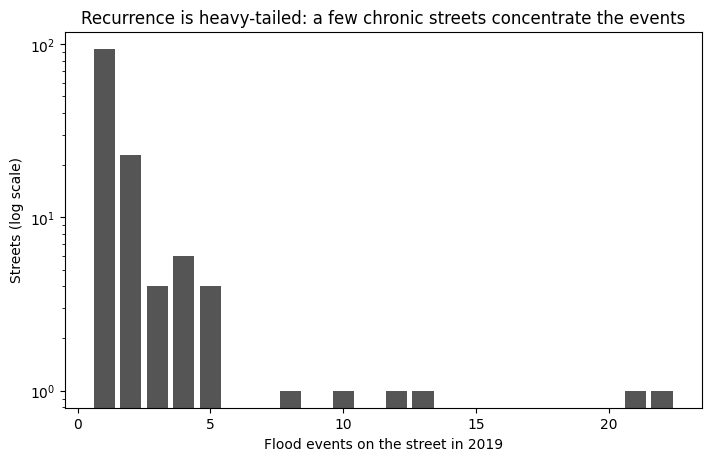

                                name  ...      highway
202              Ponte das Bandeiras  ...        trunk
6159                Avenida Mercúrio  ...      primary
7079               Avenida Brás Leme  ...      primary
1048              Avenida Rio Branco  ...      primary
255                Praça da Bandeira  ...     tertiary
1173               Rua da Cantareira  ...     tertiary
1050              Avenida Rio Branco  ...      primary
1936             Rua Barão de Duprat  ...  residential
4499                   Alameda Glete  ...  residential
6390  Rua Presidente Batista Pereira  ...    secondary

[10 rows x 4 columns]

In [5]:
# Recurrence distribution and the chronic top-10
fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")
counts = flooded["flood_count"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#555")
ax.set_yscale("log")
ax.set_xlabel("Flood events on the street in 2019")
ax.set_ylabel("Streets (log scale)")
ax.set_title("Recurrence is heavy-tailed: a few chronic streets concentrate the events")
plt.savefig(f"{FIGDIR}/recurrence_distribution.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/recurrence_distribution.pdf", bbox_inches="tight")
plt.show()

share = flooded.nlargest(10, "flood_count")["flood_count"].sum() / edges["flood_count"].sum()
print(f"The 10 most-flooded streets concentrate {share:.0%} of all {edges['flood_count'].sum():.0f} matched events")
flooded.nlargest(10, "flood_count")[["name", "flood_count", "flood_duration_h", "highway"]]

In [6]:
# Chronic (>=2 events) vs one-time flooded streets: same test battery as section 1,
# restricted to the 137 flooded streets. Also Spearman of event count among flooded only,
# to check whether the signature deepens monotonically with recurrence.
chronic = flooded[flooded["flood_count"] >= 2]
one_time = flooded[flooded["flood_count"] == 1]
print(f"{len(chronic)} chronic vs {len(one_time)} one-time flooded streets")

rows = []
for c in plot_cols:
    a, b = chronic[c].dropna(), one_time[c].dropna()
    U, p = mannwhitneyu(a, b, alternative="two-sided")
    rbc = 2 * U / (len(a) * len(b)) - 1
    ok = flooded[[c, "flood_count"]].dropna()
    rho, p_rho = spearmanr(ok[c], ok["flood_count"])
    rows.append({"metric": LABELS[c],
                 "median_chronic": chronic[c].median(), "median_one_time": one_time[c].median(),
                 "p_MWU": p, "rank_biserial": rbc,
                 "spearman_count_flooded_only": rho, "p_spearman": p_rho})

recur = pd.DataFrame(rows)
recur["p_MWU_BH"] = multipletests(recur["p_MWU"], method="fdr_bh")[1]
recur["p_spearman_BH"] = multipletests(recur["p_spearman"], method="fdr_bh")[1]
recur.to_csv(f"{RESDIR}/recurrence_tests.csv", index=False)
recur.round(4)

43 chronic vs 94 one-time flooded streets
Out[1]: 
                      metric  median_chronic  ...  p_MWU_BH  p_spearman_BH
0                     Degree          5.0000  ...    0.7677         0.6032
1  Mean shortest path length         25.9756  ...    0.4831         0.4151
2                  Closeness          0.0385  ...    0.4831         0.4151
3                Betweenness          0.0056  ...    0.9058         0.6886
4        Subgraph centrality         10.7094  ...    0.8965         0.6886
5                   PageRank          0.0001  ...    0.5398         0.5800
6              Vulnerability          0.0001  ...    0.4831         0.4151
7              Elevation (m)        732.0000  ...    0.8965         0.6504
8             Absolute grade          0.0280  ...    0.4831         0.4151

[9 rows x 9 columns]


                      metric  median_chronic  ...  p_MWU_BH  p_spearman_BH
0                     Degree          5.0000  ...    0.7677         0.6032
1  Mean shortest path length         25.9756  ...    0.4831         0.4151
2                  Closeness          0.0385  ...    0.4831         0.4151
3                Betweenness          0.0056  ...    0.9058         0.6886
4        Subgraph centrality         10.7094  ...    0.8965         0.6886
5                   PageRank          0.0001  ...    0.5398         0.5800
6              Vulnerability          0.0001  ...    0.4831         0.4151
7              Elevation (m)        732.0000  ...    0.8965         0.6504
8             Absolute grade          0.0280  ...    0.4831         0.4151

[9 rows x 9 columns]

## 2. Elevation-controlled regression

The central question for the paper: **do network-centrality effects survive controlling for terrain?**
São Paulo's arterial avenues often run along valley bottoms (fundo de vale), so centrality could be a
proxy for elevation. We fit logistic models of `flood_any` on terrain + street attributes, adding the
centralities, and a negative binomial model on `flood_count` with street length as exposure offset.
Continuous predictors are standardized, so logit coefficients are per standard deviation.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

NEEDED = ["elevation", "grade_abs", "length", "lanes"] + list(CENTRALITIES)
n_bad = edges[NEEDED].isna().any(axis=1).sum()
print(f"Edges dropped for missing values: {n_bad} of {len(edges)}")
me = edges.dropna(subset=NEEDED).reset_index(drop=True)  # model_edges

def zscore(s):
    return (s - s.mean()) / s.std()

X_base = pd.DataFrame({
    "elevation": zscore(me["elevation"]),
    "grade_abs": zscore(me["grade_abs"]),
    "log_length": zscore(np.log(me["length"])),
    "lanes": zscore(me["lanes"]),
})
top_hw = me["highway"].value_counts().nlargest(5).index
hw = me["highway"].where(me["highway"].isin(top_hw), "other")
X_base = pd.concat([X_base, pd.get_dummies(hw, prefix="hw", drop_first=True).astype(float)], axis=1)

X_cent = me[list(CENTRALITIES)].apply(zscore)
X_cent.columns = [c.replace(" ", "_") for c in X_cent.columns]

X_full = sm.add_constant(pd.concat([X_base, X_cent], axis=1))
y = me["flood_any"].astype(int)

vif = pd.Series([variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])],
                index=X_full.columns, name="VIF")
print("Variance inflation factors (rule of thumb: > 10 means strong collinearity):")
print(vif.drop("const").round(1).sort_values(ascending=False))

Edges dropped for missing values: 0 of 8714
Variance inflation factors (rule of thumb: > 10 means strong collinearity):
Closeness                    29.6
Mean_Shortest_Path_Length    28.8
Degree                       12.8
Subgraph_Centrality           6.1
hw_residential                4.4
Pagerank                      4.2
hw_primary                    3.2
hw_tertiary                   3.2
hw_secondary                  2.7
lanes                         2.4
hw_trunk                      2.0
vulnerability                 1.4
bet                           1.3
log_length                    1.2
elevation                     1.1
grade_abs                     1.1
Name: VIF, dtype: float64


In [8]:
# Full model (all centralities at once) - interpret with the VIFs above in mind
try:
    logit_full = sm.Logit(y, X_full).fit(disp=0, maxiter=500)
except Exception:
    logit_full = sm.Logit(y, X_full).fit(disp=0, maxiter=500, method="bfgs")
print(logit_full.summary())

                           Logit Regression Results                           
Dep. Variable:              flood_any   No. Observations:                 8714
Model:                          Logit   Df Residuals:                     8697
Method:                           MLE   Df Model:                           16
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.1384
Time:                        18:51:51   Log-Likelihood:                -607.30
converged:                       True   LL-Null:                       -704.84
Covariance Type:            nonrobust   LLR p-value:                 7.824e-33
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -6.2780      0.725     -8.658      0.000      -7.699      -4.857
elevation                    -1.0399      0.162     -6.439      0.000      -1.356     

Out[1]: 
                  centrality  odds_ratio_per_SD  ...  p_elevation    p_BH
0                     Degree             1.4380  ...          0.0  0.0005
1  Mean_Shortest_Path_Length             0.5926  ...          0.0  0.0000
2                  Closeness             1.6067  ...          0.0  0.0000
3                        bet             1.0867  ...          0.0  0.2541
4        Subgraph_Centrality             1.2435  ...          0.0  0.0035
5                   Pagerank             1.1905  ...          0.0  0.1233
6              vulnerability             1.0541  ...          0.0  0.2348

[7 rows x 8 columns]


<ipython-input-1-341ff330a48a>:41: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



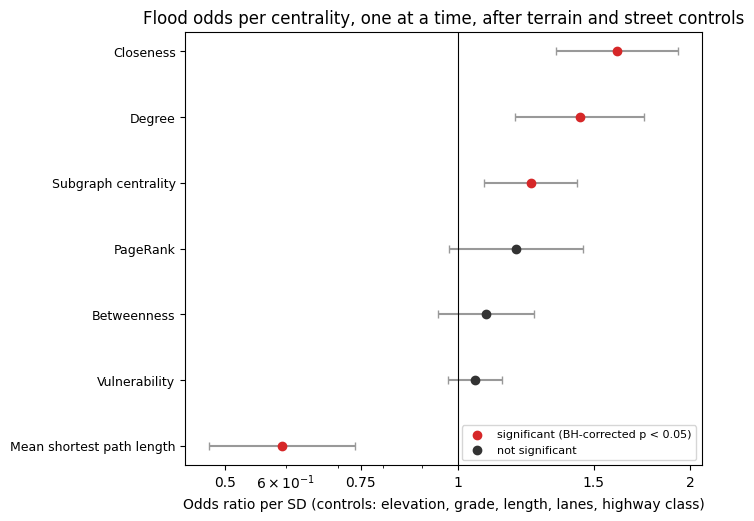

                  centrality  odds_ratio_per_SD  ...  p_elevation    p_BH
0                     Degree             1.4380  ...          0.0  0.0005
1  Mean_Shortest_Path_Length             0.5926  ...          0.0  0.0000
2                  Closeness             1.6067  ...          0.0  0.0000
3                        bet             1.0867  ...          0.0  0.2541
4        Subgraph_Centrality             1.2435  ...          0.0  0.0035
5                   Pagerank             1.1905  ...          0.0  0.1233
6              vulnerability             1.0541  ...          0.0  0.2348

[7 rows x 8 columns]

In [9]:
# One-centrality-at-a-time models: same terrain/street controls, one centrality each.
# This sidesteps the centrality-vs-centrality collinearity and is the headline table.
rows = []
for c in X_cent.columns:
    Xi = sm.add_constant(pd.concat([X_base, X_cent[[c]]], axis=1))
    res = sm.Logit(y, Xi).fit(disp=0, maxiter=300)
    lo, hi = np.exp(res.conf_int().loc[c])
    rows.append({"centrality": c, "odds_ratio_per_SD": np.exp(res.params[c]),
                 "CI95_low": lo, "CI95_high": hi, "p": res.pvalues[c],
                 "elevation_OR": np.exp(res.params["elevation"]), "p_elevation": res.pvalues["elevation"]})

oat = pd.DataFrame(rows)
oat["p_BH"] = multipletests(oat["p"], method="fdr_bh")[1]
oat.to_csv(f"{RESDIR}/logit_one_centrality_at_a_time.csv", index=False)

# Odds-ratio plot: one row per metric, log scale, OR = 1 reference line
plot_lab = {c.replace(" ", "_"): LABELS[c] for c in CENTRALITIES}
op = oat.copy()
op["label"] = op["centrality"].map(plot_lab)
op = op.sort_values("odds_ratio_per_SD").reset_index(drop=True)
sig = op["p_BH"] < 0.05
fig, ax = plt.subplots(figsize=(7, 0.5 * len(op) + 1.6), layout="constrained")
ax.errorbar(op["odds_ratio_per_SD"], np.arange(len(op)),
            xerr=[op["odds_ratio_per_SD"] - op["CI95_low"], op["CI95_high"] - op["odds_ratio_per_SD"]],
            fmt="none", ecolor="#999", capsize=3)
ax.scatter(op.loc[sig, "odds_ratio_per_SD"], np.flatnonzero(sig), color="#d62728", zorder=3,
           label="significant (BH-corrected p < 0.05)")
ax.scatter(op.loc[~sig, "odds_ratio_per_SD"], np.flatnonzero(~sig), color="#333", zorder=3,
           label="not significant")
ax.axvline(1, color="k", lw=0.8)
ax.set_xscale("log")
ax.set_xticks([0.5, 0.75, 1.0, 1.5, 2.0])
ax.set_xticklabels(["0.5", "0.75", "1", "1.5", "2"])
ax.set_yticks(np.arange(len(op)))
ax.set_yticklabels(op["label"], fontsize=9)
ax.set_xlabel("Odds ratio per SD (controls: elevation, grade, length, lanes, highway class)")
ax.set_title("Flood odds per centrality, one at a time, after terrain and street controls")
ax.legend(fontsize=8, loc="lower right")
plt.savefig(f"{FIGDIR}/logit_odds_ratios.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/logit_odds_ratios.pdf", bbox_inches="tight")
plt.show()

oat.round(4)

In [10]:
# Count model on the number of events, with log(street length) as exposure offset
# (longer streets mechanically catch more matched events). With 98% zeros the NB
# dispersion MLE degenerates, so we use a Poisson GLM with HC1 robust standard
# errors (valid under overdispersion) and a fixed-alpha NB GLM as a robustness check.
X_nb = sm.add_constant(pd.concat([X_base.drop(columns="log_length"), X_cent], axis=1))
offset = np.log(me["length"])

pois = sm.GLM(me["flood_count"], X_nb, family=sm.families.Poisson(), offset=offset).fit(cov_type="HC1")
print(pois.summary())

nb1 = sm.GLM(me["flood_count"], X_nb, family=sm.families.NegativeBinomial(alpha=1.0),
             offset=offset).fit(cov_type="HC1")
count_or = pd.DataFrame({
    "rate_ratio_poisson": np.exp(pois.params), "p_poisson": pois.pvalues,
    "rate_ratio_NB(a=1)": np.exp(nb1.params), "p_NB": nb1.pvalues,
}).drop("const")
count_or.to_csv(f"{RESDIR}/count_model_rate_ratios.csv")
count_or.round(4)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            flood_count   No. Observations:                 8714
Model:                            GLM   Df Residuals:                     8698
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1236.1
Date:                Thu, 09 Jul 2026   Deviance:                       2152.0
Time:                        18:51:52   Pearson chi2:                 3.27e+04
No. Iterations:                     9   Pseudo R-squ. (CS):            0.04825
Covariance Type:                  HC1                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

                           rate_ratio_poisson  ...    p_NB
elevation                              0.3214  ...  0.0000
grade_abs                              1.0170  ...  0.8328
lanes                                  1.5322  ...  0.0079
hw_primary                            14.8413  ...  0.0017
hw_residential                         6.7409  ...  0.0215
hw_secondary                           8.3813  ...  0.0107
hw_tertiary                            8.3915  ...  0.0177
hw_trunk                              10.7206  ...  0.0032
Degree                                 2.8448  ...  0.0189
Mean_Shortest_Path_Length              0.9040  ...  0.8703
Closeness                              1.5579  ...  0.4225
bet                                    0.9508  ...  0.5963
Subgraph_Centrality                    0.6384  ...  0.0718
Pagerank                               0.6488  ...  0.1044
vulnerability                          0.8918  ...  0.2137

[15 rows x 4 columns]

## 3. Predictive model with spatial cross-validation

Can flood-prone streets be flagged from topology + terrain alone? Folds are blocked by district
(edges from the same district never appear in both train and test), so the scores are not inflated
by spatial leakage. With ~2% positives, PR-AUC (average precision) is the honest headline number;
the baseline for a random classifier equals the positive prevalence.

In [11]:
# Assign each edge to a district via its midpoint (buffer-ring edges get "BUFFER");
# midpoints computed in the metric CRS, then joined in the districts' CRS
districts = gpd.read_file("Shapes/DI2010_RMSP_CEM.shp").to_crs(edges.crs)
mid_pts = me.geometry.to_crs(CRS_METRIC).interpolate(0.5, normalized=True).to_crs(edges.crs)
joined = gpd.sjoin(gpd.GeoDataFrame(geometry=mid_pts), districts[["NOME", "geometry"]],
                   how="left", predicate="within")
joined = joined[~joined.index.duplicated()]
me["district"] = joined["NOME"].fillna("BUFFER").values

print(me.groupby("district")["flood_any"].agg(edges="size", flooded="sum").sort_values("edges", ascending=False))

                 edges  flooded
district                       
VILA MARIANA       736        1
CAMBUCI            691        6
BOM RETIRO         672       19
SANTA CECILIA      619       17
REPUBLICA          617       23
CONSOLACAO         585        1
LIBERDADE          576        5
SE                 484       26
BELA VISTA         445        7
JARDIM PAULISTA    436        1
IPIRANGA           427        3
PERDIZES           419        0
BRAS               397        3
MOOCA              394        0
BARRA FUNDA        280        8
SANTANA            261       11
PARI               259        2
CASA VERDE         217        3
PINHEIROS          147        0
MOEMA               38        0
VILA GUILHERME      14        1


In [12]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

feat = me[list(CENTRALITIES) + ["elevation", "grade_abs", "lanes", "highway_code"]].copy()
feat["log_length"] = np.log(me["length"])
y_ml = me["flood_any"].astype(int).values
groups = me["district"].values

models = {
    "RandomForest": RandomForestClassifier(n_estimators=500, class_weight="balanced",
                                           min_samples_leaf=5, random_state=0, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=0),
}

cv = GroupKFold(n_splits=5)
proba = {name: np.zeros(len(y_ml)) for name in models}
for name, model in models.items():
    for tr, te in cv.split(feat, y_ml, groups):
        model.fit(feat.iloc[tr], y_ml[tr])
        proba[name][te] = model.predict_proba(feat.iloc[te])[:, 1]
    print(f"{name:>22}: ROC-AUC = {roc_auc_score(y_ml, proba[name]):.3f}, "
          f"PR-AUC = {average_precision_score(y_ml, proba[name]):.3f} "
          f"(chance PR-AUC = {y_ml.mean():.3f})")

for k, (tr, te) in enumerate(cv.split(feat, y_ml, groups)):
    print(f"fold {k}: {len(te)} test edges, {y_ml[te].sum()} positives, "
          f"districts = {sorted(set(groups[te]))}")

          RandomForest: ROC-AUC = 0.736, PR-AUC = 0.036 (chance PR-AUC = 0.016)
  HistGradientBoosting: ROC-AUC = 0.675, PR-AUC = 0.027 (chance PR-AUC = 0.016)
fold 0: 1786 test edges, 8 positives, districts = ['BRAS', 'CASA VERDE', 'JARDIM PAULISTA', 'VILA MARIANA']
fold 1: 1822 test edges, 18 positives, districts = ['BELA VISTA', 'CAMBUCI', 'IPIRANGA', 'PARI']
fold 2: 1722 test edges, 45 positives, districts = ['BOM RETIRO', 'PERDIZES', 'PINHEIROS', 'SE']
fold 3: 1641 test edges, 23 positives, districts = ['LIBERDADE', 'MOEMA', 'MOOCA', 'SANTA CECILIA', 'VILA GUILHERME']
fold 4: 1743 test edges, 43 positives, districts = ['BARRA FUNDA', 'CONSOLACAO', 'REPUBLICA', 'SANTANA']


Out[1]: 
elevation                    0.0063
Mean Shortest Path Length    0.0058
Subgraph Centrality          0.0007
highway_code                 0.0001
Degree                       0.0001
log_length                  -0.0000
lanes                       -0.0009
Closeness                   -0.0010
vulnerability               -0.0011
grade_abs                   -0.0015
Pagerank                    -0.0022
bet                         -0.0028
dtype: float64


<ipython-input-1-250b8ab8d897>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



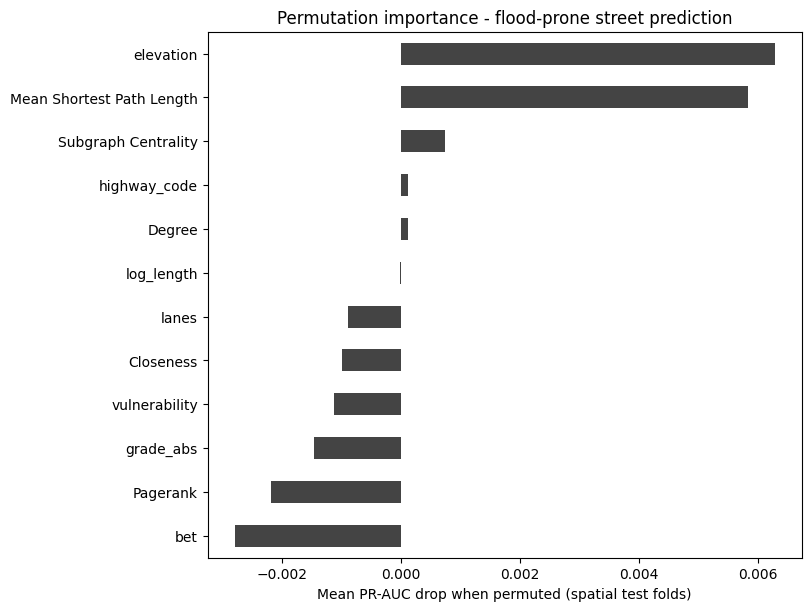

elevation                    0.0063
Mean Shortest Path Length    0.0058
Subgraph Centrality          0.0007
highway_code                 0.0001
Degree                       0.0001
log_length                  -0.0000
lanes                       -0.0009
Closeness                   -0.0010
vulnerability               -0.0011
grade_abs                   -0.0015
Pagerank                    -0.0022
bet                         -0.0028
dtype: float64

In [13]:
from sklearn.inspection import permutation_importance

# Permutation importance evaluated on each spatial test fold, then averaged
imp = np.zeros(feat.shape[1])
for tr, te in cv.split(feat, y_ml, groups):
    m = HistGradientBoostingClassifier(class_weight="balanced", random_state=0).fit(feat.iloc[tr], y_ml[tr])
    r = permutation_importance(m, feat.iloc[te], y_ml[te], scoring="average_precision",
                               n_repeats=10, random_state=0, n_jobs=-1)
    imp += r.importances_mean
imp = pd.Series(imp / cv.get_n_splits(), index=feat.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
imp.plot.barh(ax=ax, color="#444")
ax.set_xlabel("Mean PR-AUC drop when permuted (spatial test folds)")
ax.set_title("Permutation importance - flood-prone street prediction")
plt.savefig(f"{FIGDIR}/permutation_importance.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/permutation_importance.pdf", bbox_inches="tight")
plt.show()
imp.sort_values(ascending=False).round(4)

<ipython-input-1-958715625654>:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



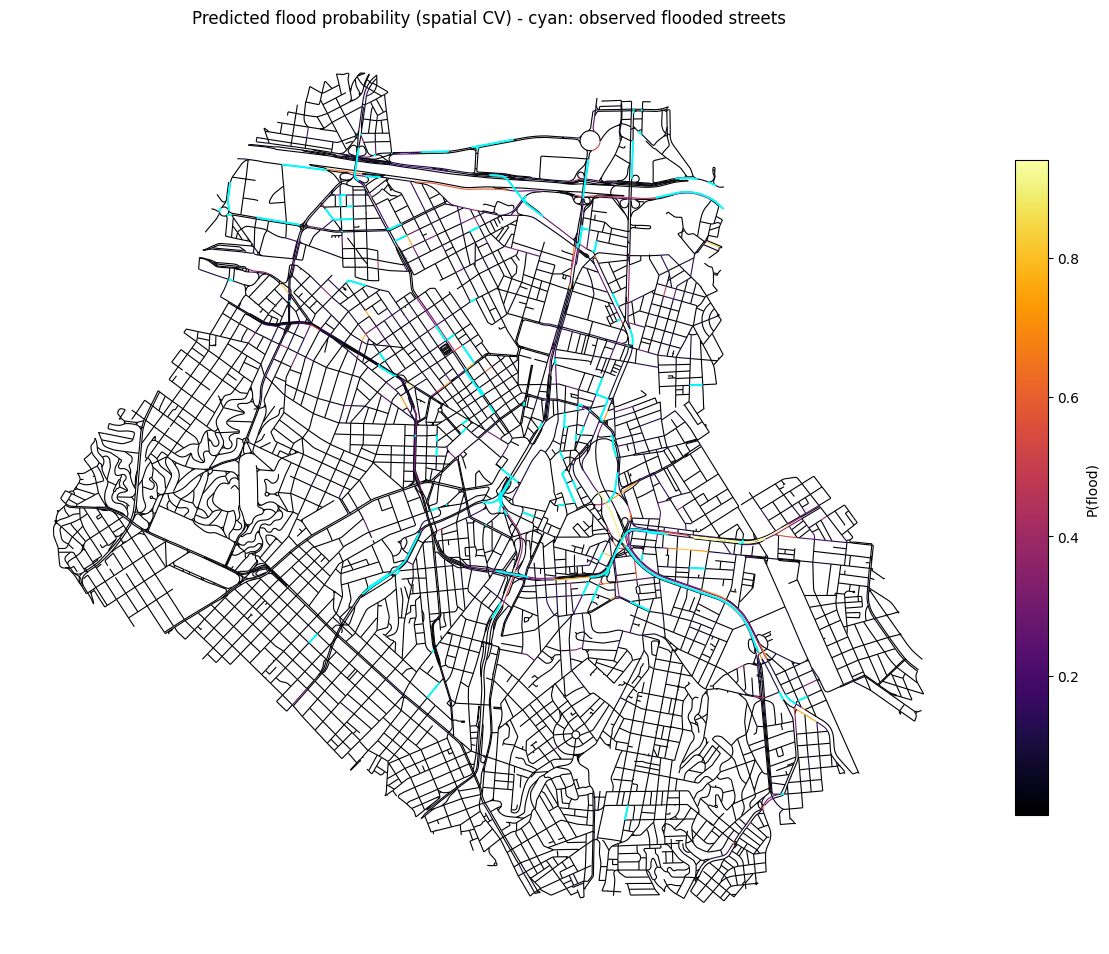

In [14]:
# Map of the cross-validated flood probability (never predicted by a model that saw the district)
me["p_flood"] = proba["HistGradientBoosting"]
fig, ax = plt.subplots(figsize=(11, 11), layout="constrained")
me.sort_values("p_flood").plot(column="p_flood", cmap="inferno", linewidth=0.8, ax=ax,
                               legend=True, legend_kwds={"shrink": 0.6, "label": "P(flood)"})
me[me["flood_any"]].plot(ax=ax, color="cyan", linewidth=1.4)
ax.set_title("Predicted flood probability (spatial CV) - cyan: observed flooded streets")
ax.axis("off")
plt.savefig(f"{FIGDIR}/flood_probability_map.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/flood_probability_map.pdf", bbox_inches="tight")
plt.show()

## 4. Resilience: what do floods do to the network?

Remove the flooded edges (as during a storm where all flood points are active) and measure the
degradation of network efficiency and connectivity, against two baselines: random removal of the same
number of edges, and targeted removal of the top-betweenness edges (worst case). Efficiency is
approximated from BFS distances out of a fixed random sample of source nodes (same sources for every
scenario, so values are directly comparable).

In [15]:
import networkx as nx
import osmnx as ox

G = ox.load_graphml("central_graph.graphml",
                    edge_dtypes={"flood_count": int, "flood_any": lambda x: x == "True",
                                 "flood_duration_h": float, "bet": float})
print(G)

N_SOURCES = 250

def approx_efficiency(H, n_sources=N_SOURCES, seed=0):
    nodes = list(H)
    sources = random.Random(seed).sample(nodes, min(n_sources, len(nodes)))
    total = 0.0
    for s in sources:
        spl = nx.single_source_shortest_path_length(H, s)
        total += sum(1.0 / d for d in spl.values() if d > 0)
    return total / (len(sources) * (len(nodes) - 1))

def measure_removal(G, edges_to_remove):
    H = G.copy()
    H.remove_edges_from(edges_to_remove)
    gc = max(nx.connected_components(H), key=len)
    return approx_efficiency(H), len(gc) / len(H)

flooded_edges = [e for e, a in nx.get_edge_attributes(G, "flood_any").items() if a]
bet = nx.get_edge_attributes(G, "bet")
all_edges = list(G.edges(keys=True))
n_f = len(flooded_edges)
print(f"{n_f} flooded edges out of {len(all_edges)}")

MultiGraph with 5637 nodes and 8714 edges
137 flooded edges out of 8714


In [16]:
base_eff = approx_efficiency(G)

eff_flood, gc_flood = measure_removal(G, flooded_edges)
top_bet = sorted(bet, key=bet.get, reverse=True)[:n_f]
eff_bet, gc_bet = measure_removal(G, top_bet)

rng = random.Random(42)
rand = [measure_removal(G, rng.sample(all_edges, n_f)) for _ in range(100)]
rand_eff = np.array([r[0] for r in rand]); rand_gc = np.array([r[1] for r in rand])

resil = pd.DataFrame([
    {"scenario": "intact network", "efficiency": base_eff, "eff_drop_%": 0.0, "giant_component": 1.0},
    {"scenario": f"remove {n_f} flooded edges", "efficiency": eff_flood,
     "eff_drop_%": 100 * (1 - eff_flood / base_eff), "giant_component": gc_flood},
    {"scenario": f"remove {n_f} random edges (mean of 100)", "efficiency": rand_eff.mean(),
     "eff_drop_%": 100 * (1 - rand_eff.mean() / base_eff), "giant_component": rand_gc.mean()},
    {"scenario": f"remove top-{n_f} betweenness edges", "efficiency": eff_bet,
     "eff_drop_%": 100 * (1 - eff_bet / base_eff), "giant_component": gc_bet},
])
z = (base_eff - eff_flood - (base_eff - rand_eff).mean()) / (base_eff - rand_eff).std()
print(f"Flood-removal efficiency drop vs random baseline: z = {z:.2f} "
      f"(random drops: {100 * (1 - rand_eff / base_eff).mean():.2f}% +/- {100 * (rand_eff / base_eff).std():.2f}%)")
resil.to_csv(f"{RESDIR}/resilience_summary.csv", index=False)
resil.round(4)

Flood-removal efficiency drop vs random baseline: z = 4.35 (random drops: 1.78% +/- 0.65%)
Out[1]: 
                                scenario  ...  giant_component
0                         intact network  ...           1.0000
1               remove 137 flooded edges  ...           0.9996
2  remove 137 random edges (mean of 100)  ...           0.9984
3       remove top-137 betweenness edges  ...           0.9986

[4 rows x 4 columns]


                                scenario  ...  giant_component
0                         intact network  ...           1.0000
1               remove 137 flooded edges  ...           0.9996
2  remove 137 random edges (mean of 100)  ...           0.9984
3       remove top-137 betweenness edges  ...           0.9986

[4 rows x 4 columns]

<ipython-input-1-1abddfe92383>:36: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



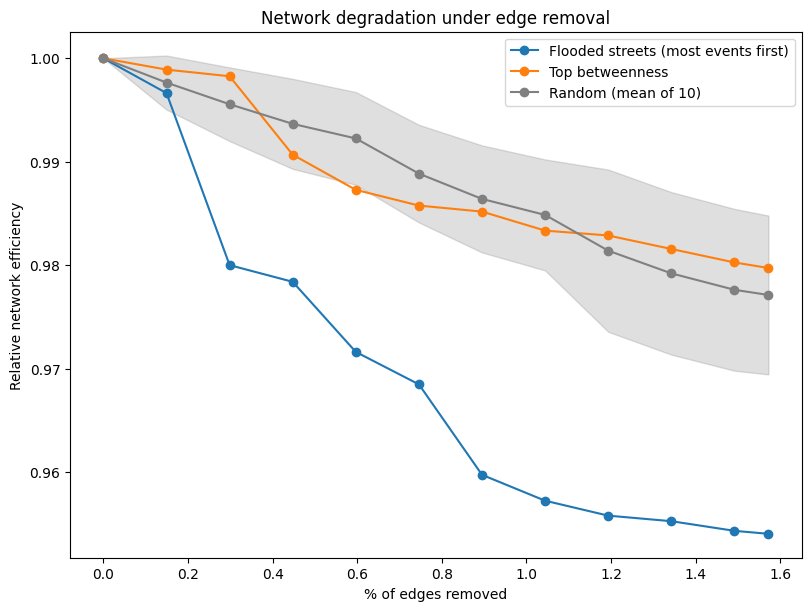

In [17]:
# Sequential removal curve: efficiency as edges are removed, worst-first per strategy
def removal_curve(G, order, steps=10):
    fracs, effs = [0.0], [approx_efficiency(G)]
    H = G.copy()
    chunk = max(1, len(order) // steps)
    for i in range(0, len(order), chunk):
        H.remove_edges_from(order[i:i + chunk])
        fracs.append(min(i + chunk, len(order)) / G.number_of_edges())
        effs.append(approx_efficiency(H))
    return np.array(fracs), np.array(effs)

orders = {
    "Flooded streets (most events first)": sorted(flooded_edges, key=lambda e: G.edges[e]["flood_count"], reverse=True),
    "Top betweenness": top_bet,
}
curves = {name: removal_curve(G, order) for name, order in orders.items()}

# Random baseline: mean of 10 random orders of the same size
rng = random.Random(7)
rand_curves = [removal_curve(G, rng.sample(all_edges, n_f))[1] for _ in range(10)]
fr = curves["Top betweenness"][0]
rand_mean = np.mean(rand_curves, axis=0); rand_std = np.std(rand_curves, axis=0)

fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
for name, (f, e) in curves.items():
    ax.plot(100 * f, e / e[0], marker="o", label=name)
ax.plot(100 * fr, rand_mean / rand_mean[0], marker="o", color="gray", label="Random (mean of 10)")
ax.fill_between(100 * fr, (rand_mean - rand_std) / rand_mean[0], (rand_mean + rand_std) / rand_mean[0],
                color="gray", alpha=0.25)
ax.set_xlabel("% of edges removed")
ax.set_ylabel("Relative network efficiency")
ax.set_title("Network degradation under edge removal")
ax.legend()
plt.savefig(f"{FIGDIR}/resilience_curves.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/resilience_curves.pdf", bbox_inches="tight")
plt.show()

## 5. Temporal analysis

<ipython-input-1-6fcd8c051d6b>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



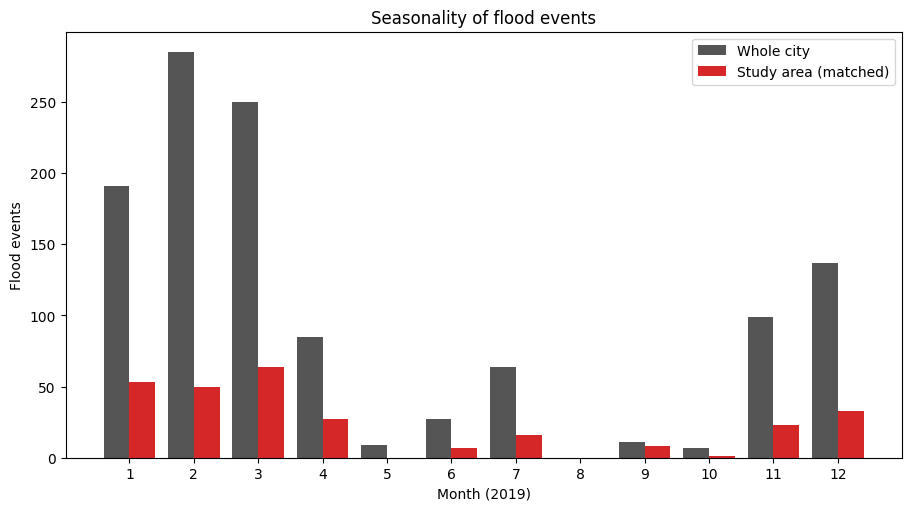

In [18]:
floods_all = pd.read_csv("floods.csv", sep=";")
matched_ev = pd.read_csv("matched_events.csv")

monthly_city = floods_all["MES"].value_counts().sort_index()
monthly_study = matched_ev["MES"].value_counts().reindex(monthly_city.index, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
x = np.arange(1, 13)
ax.bar(x - 0.2, monthly_city.reindex(x, fill_value=0), width=0.4, label="Whole city", color="#555")
ax.bar(x + 0.2, monthly_study.reindex(x, fill_value=0), width=0.4, label="Study area (matched)", color="#d62728")
ax.set_xticks(x)
ax.set_xlabel("Month (2019)")
ax.set_ylabel("Flood events")
ax.set_title("Seasonality of flood events")
ax.legend()
plt.savefig(f"{FIGDIR}/monthly_events.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/monthly_events.pdf", bbox_inches="tight")
plt.show()

In [19]:
# Rainy season (Dec-Mar) vs dry season: does the flooded/non-flooded contrast hold in both?
RAINY = {12, 1, 2, 3}
matched_ev["season"] = np.where(matched_ev["MES"].isin(RAINY), "rainy", "dry")
per_edge = matched_ev.groupby(["u", "v", "key", "season"]).size().unstack(fill_value=0)
for s in ("rainy", "dry"):
    if s not in per_edge:
        per_edge[s] = 0
seasonal = edges.merge(per_edge.reset_index(), on=["u", "v", "key"], how="left").fillna({"rainy": 0, "dry": 0})

rows = []
for season in ("rainy", "dry"):
    fl = seasonal[seasonal[season] > 0]
    nf = seasonal[seasonal[season] == 0]
    for c in CENTRALITIES:
        U, p = mannwhitneyu(fl[c].dropna(), nf[c].dropna(), alternative="two-sided")
        rbc = 2 * U / (len(fl[c].dropna()) * len(nf[c].dropna())) - 1
        rows.append({"season": season, "n_flooded": len(fl), "metric": LABELS[c],
                     "p_MWU": p, "rank_biserial": rbc})
seasonal_tests = pd.DataFrame(rows)
seasonal_tests["p_BH"] = multipletests(seasonal_tests["p_MWU"], method="fdr_bh")[1]
seasonal_tests.to_csv(f"{RESDIR}/seasonal_tests.csv", index=False)
seasonal_tests.round(4)

Out[1]: 
   season  n_flooded                     metric   p_MWU  rank_biserial    p_BH
0   rainy        108                     Degree  0.0065         0.1430  0.0101
1   rainy        108  Mean shortest path length  0.0000        -0.2481  0.0000
2   rainy        108                  Closeness  0.0000         0.2481  0.0000
3   rainy        108                Betweenness  0.0000         0.2996  0.0000
4   rainy        108        Subgraph centrality  0.0834         0.0968  0.0973
5   rainy        108                   PageRank  0.3478         0.0525  0.3478
6   rainy        108              Vulnerability  0.0000         0.3423  0.0000
7     dry         47                     Degree  0.0028         0.2371  0.0049
8     dry         47  Mean shortest path length  0.0000        -0.4583  0.0000
9     dry         47                  Closeness  0.0000         0.4583  0.0000
10    dry         47                Betweenness  0.0091         0.2201  0.0128
11    dry         47        Subgraph centra

   season  n_flooded                     metric   p_MWU  rank_biserial    p_BH
0   rainy        108                     Degree  0.0065         0.1430  0.0101
1   rainy        108  Mean shortest path length  0.0000        -0.2481  0.0000
2   rainy        108                  Closeness  0.0000         0.2481  0.0000
3   rainy        108                Betweenness  0.0000         0.2996  0.0000
4   rainy        108        Subgraph centrality  0.0834         0.0968  0.0973
5   rainy        108                   PageRank  0.3478         0.0525  0.3478
6   rainy        108              Vulnerability  0.0000         0.3423  0.0000
7     dry         47                     Degree  0.0028         0.2371  0.0049
8     dry         47  Mean shortest path length  0.0000        -0.4583  0.0000
9     dry         47                  Closeness  0.0000         0.4583  0.0000
10    dry         47                Betweenness  0.0091         0.2201  0.0128
11    dry         47        Subgraph centrality  0.0

In [20]:
# Duration-weighted view: correlate metrics with total flooded hours per street
rows = []
for c in list(CENTRALITIES) + TERRAIN:
    ok = edges[[c, "flood_duration_h"]].dropna()
    rho, p = spearmanr(ok[c], ok["flood_duration_h"])
    rows.append({"metric": LABELS[c], "spearman_vs_duration_h": rho, "p": p})
dur = pd.DataFrame(rows)
dur["p_BH"] = multipletests(dur["p"], method="fdr_bh")[1]
dur.to_csv(f"{RESDIR}/duration_correlations.csv", index=False)
dur.round(4)

Out[1]: 
                      metric  spearman_vs_duration_h       p    p_BH
0                     Degree                  0.0370  0.0006  0.0008
1  Mean shortest path length                 -0.0615  0.0000  0.0000
2                  Closeness                  0.0615  0.0000  0.0000
3                Betweenness                  0.0571  0.0000  0.0000
4        Subgraph centrality                  0.0250  0.0197  0.0238
5                   PageRank                  0.0151  0.1599  0.1599
6              Vulnerability                  0.0739  0.0000  0.0000
7              Elevation (m)                 -0.0928  0.0000  0.0000
8             Absolute grade                 -0.0247  0.0211  0.0238


                      metric  spearman_vs_duration_h       p    p_BH
0                     Degree                  0.0370  0.0006  0.0008
1  Mean shortest path length                 -0.0615  0.0000  0.0000
2                  Closeness                  0.0615  0.0000  0.0000
3                Betweenness                  0.0571  0.0000  0.0000
4        Subgraph centrality                  0.0250  0.0197  0.0238
5                   PageRank                  0.0151  0.1599  0.1599
6              Vulnerability                  0.0739  0.0000  0.0000
7              Elevation (m)                 -0.0928  0.0000  0.0000
8             Absolute grade                 -0.0247  0.0211  0.0238

## Outputs

- `results/group_comparison_tests.csv` - Mann-Whitney U + effect sizes + Spearman vs event count
- `results/recurrence_tests.csv` - chronic (>=2 events) vs one-time flooded streets
- `results/logit_one_centrality_at_a_time.csv` - elevation-controlled odds ratios per centrality
- `results/count_model_rate_ratios.csv` - Poisson/NB rate ratios for event counts
- `results/resilience_summary.csv`, `results/seasonal_tests.csv`, `results/duration_correlations.csv`
- `figures/` - violins, recurrence distribution, permutation importance, flood-probability map, resilience curves, seasonality